# Analyse du model et interpretation des resultats

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
    .master("local[*]")\
    .appName("Accident")\
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

your 131072x1 screen size is bogus. expect trouble
25/06/18 11:17:18 WARN Utils: Your hostname, DESKTOP-NHT3FJU resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/06/18 11:17:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/18 11:17:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [7]:
from pyspark.ml.pipeline import PipelineModel

best_model = PipelineModel.load("logistic_regression_model")
# df = spark.read.parquet("../../data/processed_accidents_v2.parquet")

In [14]:
columns_to_keep = [
    "Severity",

    'Start_Lat', 'Start_Lng', 'Distance(mi)',

    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',

    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop',

    'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight',

    'Weather_Condition', 'Wind_Direction',
    'State'
]

feature_cols = columns_to_keep[1:]
feature_cols.remove("Wind_Chill(F)")

columns_to_encode = [
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
    "Weather_Condition", "Wind_Direction", "State"
]

numerical_features = [col for col in feature_cols if col not in columns_to_encode]

In [15]:
n = len(columns_to_encode)
indexers = best_model.stages[:n]
encoders = best_model.stages[n:2*n]
assembler = best_model.stages[-3]
scaler = best_model.stages[-2]
lr_model = best_model.stages[-1]

In [21]:
encoded_feature_names = []

for encoder in encoders:
    input_col = encoder.getInputCol().replace("_idx", "")
    num_categories = encoder.categorySizes[0]
    
    # Si dropLast=True, on ne crée que n-1 colonnes
    for i in range(num_categories - 1):
        encoded_feature_names.append(f"{input_col}_{i}")

full_feature_names = encoded_feature_names + numerical_features


In [24]:
import pandas as pd

coef_matrix = lr_model.coefficientMatrix.toArray()  # shape: (n_classes, n_features)

# Créer un DataFrame avec une ligne par feature et une colonne par classe
columns = [f"Classe_{i}" for i in range(coef_matrix.shape[0])]
coef_df = pd.DataFrame(coef_matrix.T, index=full_feature_names, columns=columns)

# Moyenne des poids absolus (influence globale)
coef_df["mean_abs_weight"] = coef_df.abs().mean(axis=1)


In [25]:
top_k = 15
top_features = coef_df.sort_values("mean_abs_weight", ascending=False).head(top_k)

print("Top features les plus influentes :")
display(top_features)

Top features les plus influentes :


,Classe_0,Classe_1,Classe_2,Classe_3,Classe_4,mean_abs_weight
Traffic_Signal,8.063975e-08,0.056733,0.077071,-0.120865,-0.012939,0.053522
Crossing,1.044547e-07,0.043774,0.075128,-0.106487,-0.012415,0.047561
Weather_Condition_0,1.107755e-07,0.033890,0.067808,-0.100311,-0.001387,0.040679
Weather_Condition_3,-7.278922e-08,-0.028518,-0.061586,0.078258,0.011846,0.036042
State_11,-9.332861e-08,-0.008104,-0.079222,0.046026,0.041300,0.034931
Distance(mi),-1.671698e-08,-0.020689,-0.002049,-0.056529,0.079268,0.031707
Stop,6.109051e-08,0.008232,0.054822,-0.073714,0.010660,0.029486
State_22,-6.981061e-08,-0.002754,-0.066336,0.036518,0.032572,0.027636
Temperature(F),-5.747902e-10,0.040435,-0.053622,0.027930,-0.014743,0.027346
State_0,9.955350e-08,-0.008071,0.050373,0.015195,-0.057497,0.026227


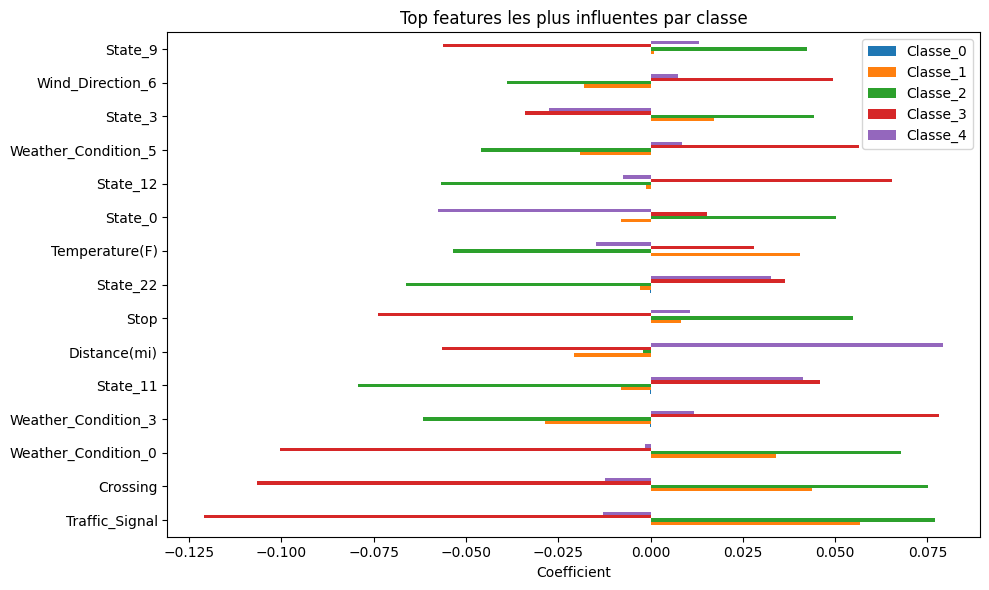

In [27]:
import matplotlib.pyplot as plt

top_features[columns].plot(kind="barh", figsize=(10, 6))
plt.title("Top features les plus influentes par classe")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.ml.feature import StringIndexerModel

encoder_model = best_model.stages[0]
labels = encoder_model.labels

indexer_labels = {}
for stage in best_model.stages:
    if isinstance(stage, StringIndexerModel):
        original_col = stage.getInputCol()
        indexer_labels[original_col] = stage.labels


def decode_feature_name(feature_name):
    for base_col in indexer_labels:
        if feature_name.startswith(base_col):
            try:
                index = int(feature_name.split("_")[-1])
                return f"{base_col}={indexer_labels[base_col][index]}"
            except:
                pass
    return feature_name  # si c’est une feature numérique


readable_index = [decode_feature_name(f) for f in coef_df.index]
coef_df.index = readable_index


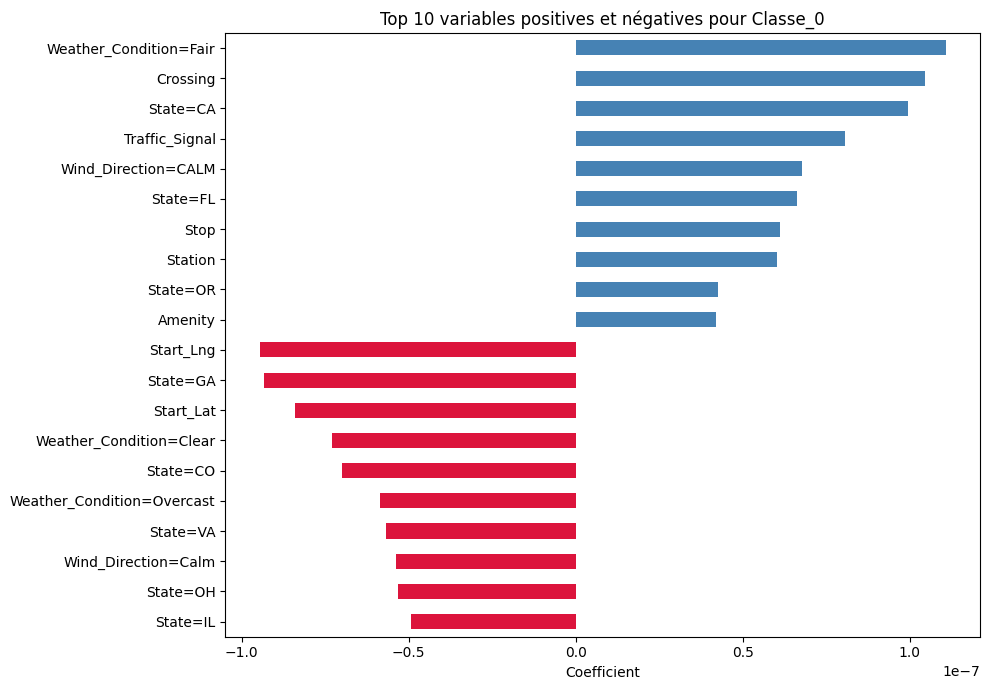

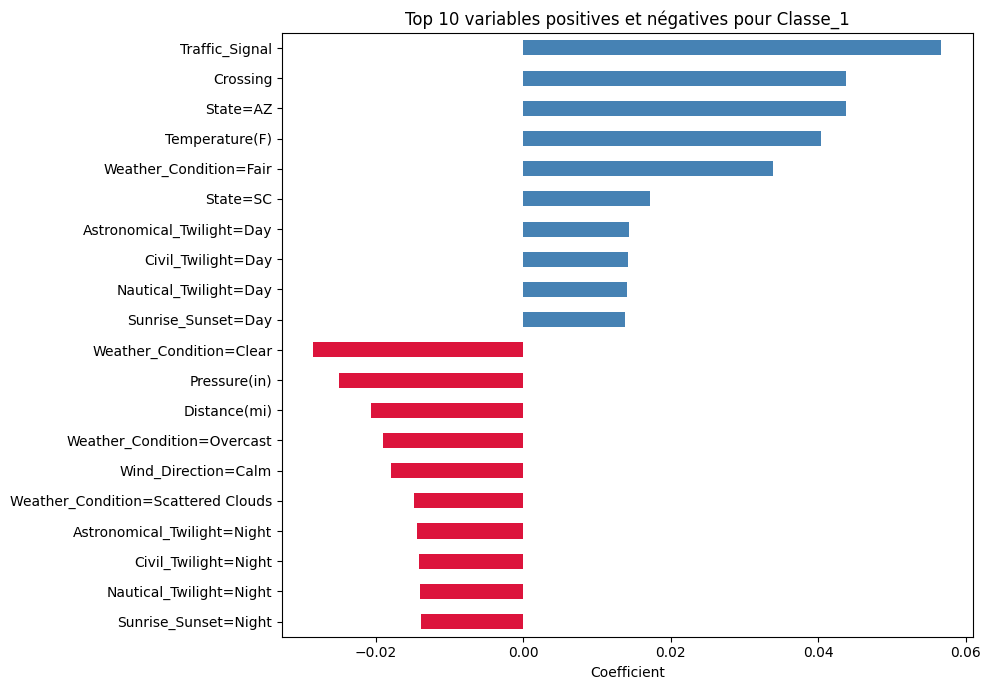

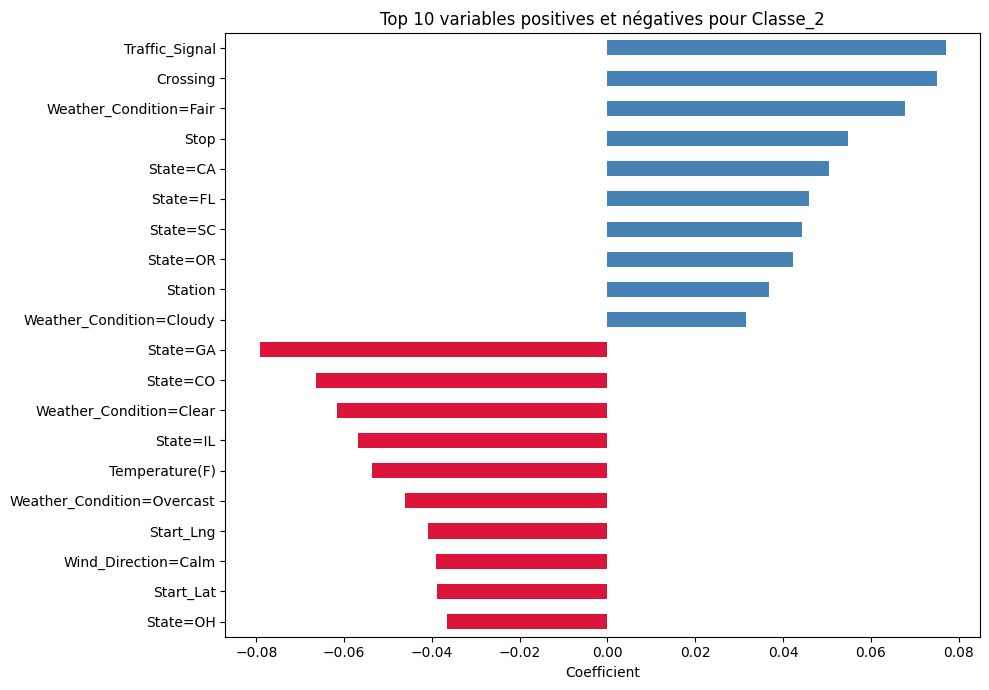

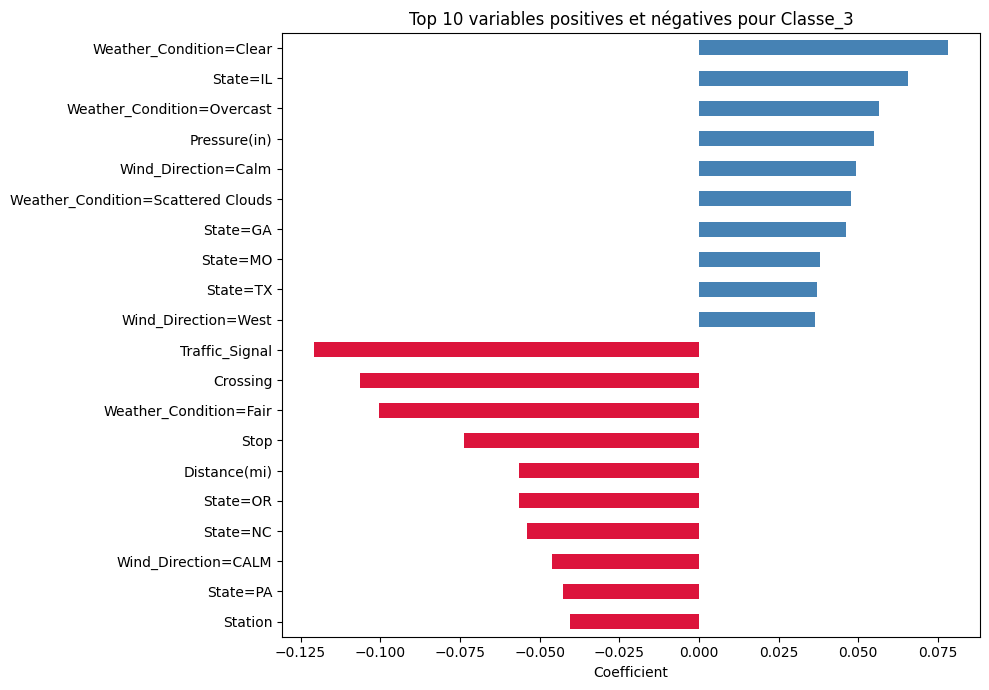

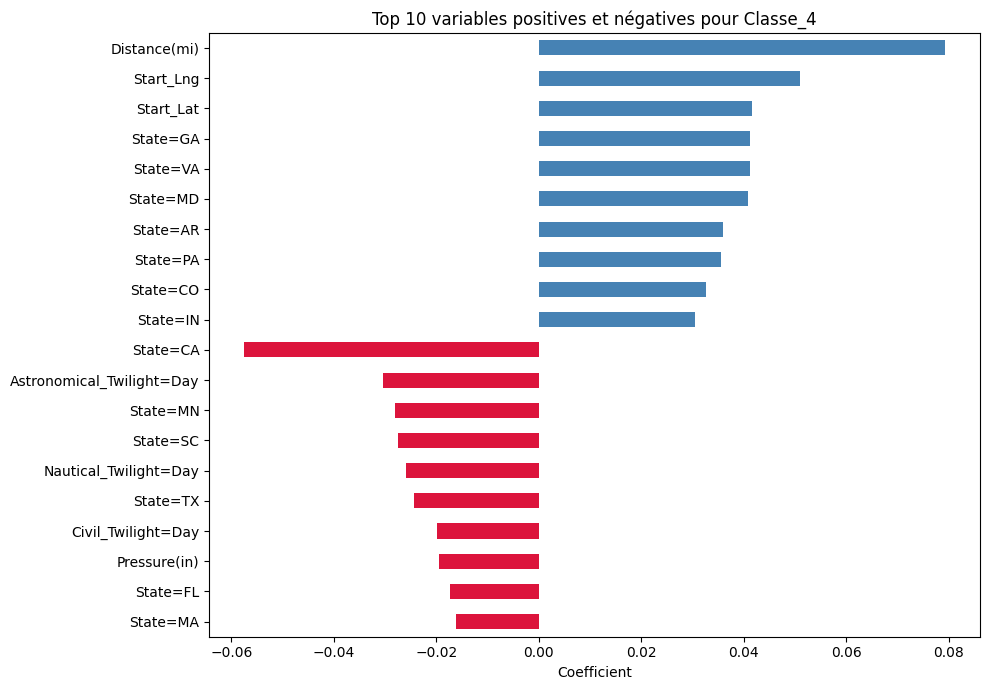

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

for col in columns:  # par exemple "Classe_0", ..., "Classe_4"
    top_pos = coef_df[col].sort_values(ascending=False).head(10)
    top_neg = coef_df[col].sort_values().head(10)
    top_features = pd.concat([top_pos, top_neg])

    plt.figure(figsize=(10, 7))
    top_features.plot(kind="barh", color=["crimson" if v < 0 else "steelblue" for v in top_features])
    plt.title(f"Top 10 variables positives et négatives pour {col}")
    plt.xlabel("Coefficient")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
